In [1]:
import pdal
import geopandas as gpd
import json
import os
from shapely.geometry import mapping

In [2]:
# Carregar feições
gdf = gpd.read_file('data/SIRGAS_GPKG_favela.gpkg')
gdf.geometry = gdf.buffer(0)

favelas_test = [
    "Heliópolis",
    "Cocaia I",
    "Paraisópolis",
    "Futuro Melhor",
    "São Remo"
]

gdf_favelas = gdf[gdf['fv_nome'].isin(favelas_test)]

/Users/fernandogomes/miniconda3/envs/pdal/lib/python3.12/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Polygon' is converted to 'Polygon Z'
  return ogr_read(


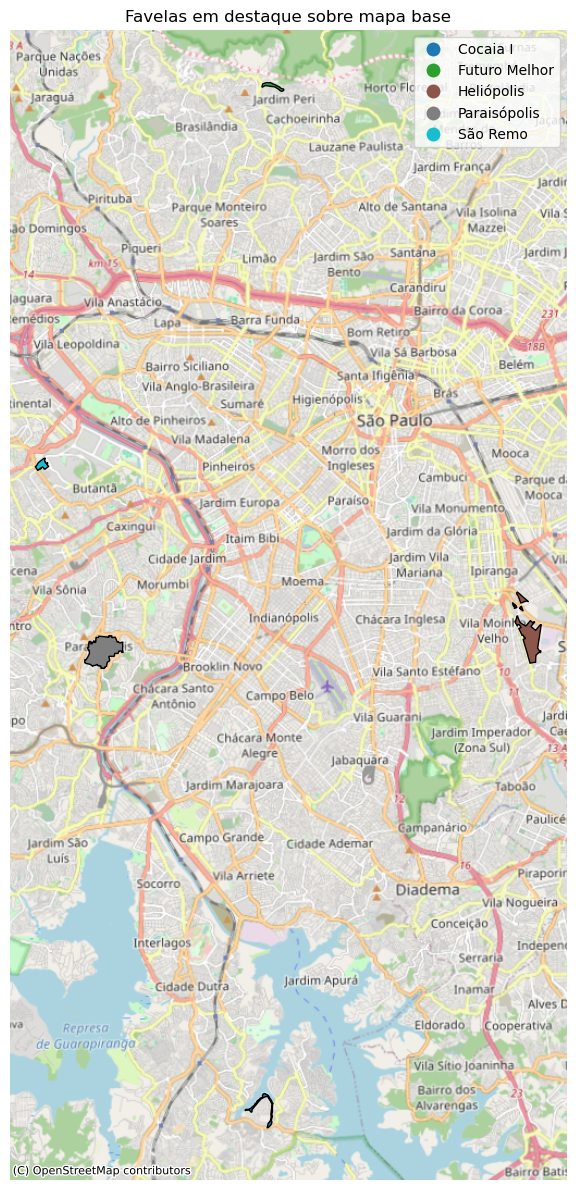

In [3]:
import contextily as ctx
import matplotlib.pyplot as plt

# Plotando as favelas filtradas com mapa base
fig, ax = plt.subplots(figsize=(20, 12))
# Filtrar as favelas de interesse
favelas_filtradas = gdf[gdf['fv_nome'].isin(favelas_test)]

# Plotando as favelas filtradas
favelas_filtradas.plot(ax=ax, alpha=1, edgecolor='black', column='fv_nome', legend=True)

# Adicionando mapa base em tons de cinza (menos saturação)
ctx.add_basemap(
    ax,
    crs=favelas_filtradas.crs,
    source=ctx.providers.OpenStreetMap.Mapnik,
    alpha=1.0
)

# Removendo eixos para dar mais destaque
ax.set_axis_off()
plt.title("Favelas em destaque sobre mapa base")
plt.tight_layout()
plt.show()

In [4]:
# Dicionário com anos, pastas e articulações
als = {
    2017: {
        "arquivos_laz": "../LiDAR-Sampa-2017",
        "articulacao": "data/quadricula_folha_mdt.zip",
        "atributo_quadricula": "cd_quadric",
        "nome_fn": lambda row, dados: f"MDS_color_{row[dados['atributo_quadricula']]}.laz"
    },
    2020: {
        "arquivos_laz": "../LiDAR-Sampa-2020",
        "articulacao": "data/quadricula_folha_mdt_mds_2020.zip",
        "atributo_quadricula": "cd_quadric",
        "nome_fn": lambda row, dados: f"MDS_{row[dados['atributo_quadricula']]}_1000.laz"
    },
    2024: {
        "arquivos_laz": "../LiDAR-Sampa-2024",
        "articulacao": "../LiDAR-Sampa-2024/poligonos_consolidados.gpkg",
        "atributo_quadricula": "nome_arquivo",
        "nome_fn": lambda row, dados: f'{row[dados["atributo_quadricula"]]}.laz' 
    }
}

# Pasta de saída geral
os.makedirs("saidas", exist_ok=True)

# loop principal - recorte e gravação
for idx, favela in gdf_favelas.iterrows():
    nome = favela["fv_nome"]
    geom = favela.geometry
    
    print(f"Processando {nome}...")

    # cria pasta de saída se não existir
    pasta_saida = os.path.join("saidas", nome.replace(" ", "_"))
    os.makedirs(pasta_saida, exist_ok=True)
 
    gdf_single = gpd.GeoDataFrame(
        {"fv_nome": [nome], "geometry": [favela.geometry]},
        crs=gdf_favelas.crs
    )

    for ano, dados in als.items():
        print(f"\n=== Processando {ano} ===")
        gdf_art = gpd.read_file(dados['articulacao'])
        gdf_art = gdf_art.to_crs(gdf_favelas.crs)

        # Recorte das feições que caem na São Remo
        recorte = gpd.overlay(gdf_art, gdf_single, how="intersection")
        als[ano]["gdf"] = recorte

        print(f"{ano}: {len(recorte)} feições sobrepostas")

        # Pasta de saída por ano
        outdir = os.path.join(pasta_saida, str(ano))
        os.makedirs(outdir, exist_ok=True)

        arquivos_saida = []


        for idx, row in recorte.iterrows():
            # Ajuste: troque 'NOME' pelo campo que identifica a folha
            nome_folha = dados["nome_fn"](row, dados)   # aqui aplica a função definida no dicionário
            arquivo_laz = os.path.join(dados["arquivos_laz"], nome_folha)
            print(arquivo_laz)

            if not os.path.exists(arquivo_laz):
                print(f"⚠️ Arquivo não encontrado: {arquivo_laz}")
                continue

            # Converter geometria em GeoJSON para o filtro do PDAL
            polygon = mapping(row.geometry)
            out_laz = os.path.join(outdir, f"{nome_folha}_recorte.laz")
            arquivos_saida.append(out_laz)

            pipeline_json = {
                "pipeline": [
                    arquivo_laz,
                    {
                        "type": "filters.crop",
                        "polygon": json.dumps(polygon)
                    },
                    {
                        "type": "filters.hag_nn"
                    },
                    {
                        "type": "filters.ferry",
                        "dimensions": "Z => Z_orig"
                    },
                    {
                        "type": "writers.las",
                        "filename": out_laz,
                        "extra_dims": "HeightAboveGround=float32,Z_orig=float32"
                    }
                ]
            }

                    
            pipeline = pdal.Pipeline(json.dumps(pipeline_json))
            pipeline.execute()
            print(f"✅ Recorte salvo: {out_laz}")

        # Juntar os recortes em um único arquivo do ano
        if arquivos_saida:
            merged_out = os.path.join(outdir, f"{nome}_{ano}.laz")
            pipeline_merge = {
                "pipeline": arquivos_saida + [
                    {
                        "type": "writers.las",
                        "filename": merged_out,
                        "extra_dims": "HeightAboveGround=float32,Z_orig=float32"
                    }
                ]
            }
            pdal.Pipeline(json.dumps(pipeline_merge)).execute()
            print(f"🎯 Nuvem final salva: {merged_out}")
        else:
            print(f"⚠️ Nenhuma nuvem processada para {ano}")
        
        # remove os arquivos individuais gerados pelo recorte
        for arquivo in arquivos_saida:
            os.remove(arquivo)
            print(f"🗑️ Arquivo temporário removido: {arquivo}")




Processando São Remo...

=== Processando 2017 ===
2017: 4 feições sobrepostas
../LiDAR-Sampa-2017/MDS_color_3313-144.laz
✅ Recorte salvo: saidas/São_Remo/2017/MDS_color_3313-144.laz_recorte.laz
../LiDAR-Sampa-2017/MDS_color_3313-143.laz
✅ Recorte salvo: saidas/São_Remo/2017/MDS_color_3313-143.laz_recorte.laz
../LiDAR-Sampa-2017/MDS_color_3313-312.laz
✅ Recorte salvo: saidas/São_Remo/2017/MDS_color_3313-312.laz_recorte.laz
../LiDAR-Sampa-2017/MDS_color_3313-311.laz
✅ Recorte salvo: saidas/São_Remo/2017/MDS_color_3313-311.laz_recorte.laz
🎯 Nuvem final salva: saidas/São_Remo/2017/São Remo_2017.laz
🗑️ Arquivo temporário removido: saidas/São_Remo/2017/MDS_color_3313-144.laz_recorte.laz
🗑️ Arquivo temporário removido: saidas/São_Remo/2017/MDS_color_3313-143.laz_recorte.laz
🗑️ Arquivo temporário removido: saidas/São_Remo/2017/MDS_color_3313-312.laz_recorte.laz
🗑️ Arquivo temporário removido: saidas/São_Remo/2017/MDS_color_3313-311.laz_recorte.laz

=== Processando 2020 ===
2020: 4 feições sobr